# **Project Name**    ->   Regression - Yes Bank Stock Closing Price Prediction



##### **Project Type**    - EDA + Regression
##### **Contribution**    - Individual


# **Project Summary -**

This project focuses on analyzing and predicting stock prices of YES BANK using exploratory data analysis (EDA), statistical testing, and machine learning techniques. The dataset consists of historical monthly stock-price records with five variables: Date, Open, High, Low, and Close. The main objective of the project was to understand the behavior of stock prices over time and build predictive models that estimate the closing price based on historical market information.

The project started with data understanding and preprocessing. The dataset was inspected for structure, variable types, unique values, missing values, and duplicate records. The Date column was converted into datetime format to make it suitable for time-series analysis. Since the dataset represents chronological stock-price observations, sorting the data by date was an important preprocessing step. Additional time-based features such as month and year were extracted where required. Outlier analysis was also performed using box plots and the interquartile range (IQR) method. However, because stock-price datasets often contain genuine market fluctuations, extreme values were treated carefully and not removed unless they indicated data errors.

Exploratory data analysis was conducted to understand trends, distribution, variability, and relationships among variables. A line chart was used to study the movement of closing prices over time, while histograms and box plots helped analyze distribution and outliers. A correlation heatmap and pair plot were used to examine relationships among Open, High, Low, and Close. These visualizations indicated that the stock variables were positively related and carried useful information for prediction.

Hypothesis testing was also performed to validate observations statistically. Paired t-tests were used to compare the mean difference between opening and closing prices, and between high and low prices. Pearson correlation analysis was applied to test the relationship between opening and closing prices. These statistical tests helped support data-driven conclusions instead of relying only on visual interpretation.

For predictive modeling, the problem was treated as a regression task because the target variable (Close) is continuous. The dataset was split chronologically into training and testing sets using an 80:20 ratio to preserve time order and avoid future information leaking into the training process. Three machine learning models were implemented: Linear Regression, Random Forest Regressor, and Decision Tree Regressor. Model performance was evaluated using R² score, Mean Absolute Error (MAE), Mean Squared Error (MSE), and Root Mean Squared Error (RMSE). These metrics helped assess both predictive accuracy and business usefulness.

Hyperparameter optimization was performed using GridSearchCV to improve model performance. The optimized models were compared with baseline models to evaluate improvements. Among all models, Random Forest Regressor was selected as the final prediction model because it captures non-linear relationships, reduces overfitting through ensemble learning, and generally provided stronger predictive performance. Feature importance from the model was used as a simple explainability technique to understand how much each input variable contributed to predicting the closing price.

Finally, the best-performing model was saved in joblib format for deployment. The saved model was reloaded and tested on unseen input data as a sanity check. Overall, the project demonstrates how EDA, statistical analysis, and machine learning can be combined to generate meaningful insights and support stock-price forecasting.

# **GitHub Link -**

Provide your GitHub Link here.

# **Problem Statement**


Yes Bank is a well - known Bank in the Indian financial domain. Since 2018, it has been in the news because of the fraud case involving Rana Kapoor. Owing to this fact, it was intersesting to see how that impacted the Stock prices of the company and whether Time series models or any other predictive models can do justice to such situations. This dataset has monthly stocks prices of the bank since its inception and includes closing, starting, highest and lowest stock prices of every month. The main objective is to predict the stock's closing price of the month.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [61]:
# Import Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.stats import ttest_rel
from scipy.stats import pearsonr
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
import joblib

### Dataset Loading

In [2]:
# Load Dataset
data = pd.read_csv('/content/data_YesBank_StockPrices.csv')

### Dataset First View

In [3]:
# Dataset First Look
data.head()

,Date,Open,High,Low,Close
0,Jul-05,13.00,14.00,11.25,12.46
1,Aug-05,12.58,14.88,12.55,13.42
2,Sep-05,13.48,14.87,12.27,13.30
3,Oct-05,13.20,14.47,12.40,12.99
4,Nov-05,13.35,13.88,12.88,13.41


### Dataset Rows & Columns count

In [4]:
# Dataset Rows & Columns count
data.shape

(185, 5)

### Dataset Information

In [5]:
# Dataset Info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 185 entries, 0 to 184
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    185 non-null    object 
 1   Open    185 non-null    float64
 2   High    185 non-null    float64
 3   Low     185 non-null    float64
 4   Close   185 non-null    float64
dtypes: float64(4), object(1)
memory usage: 7.4+ KB


#### Duplicate Values

In [6]:
# Dataset Duplicate Value Count
data.duplicated().sum()

np.int64(0)

#### Missing Values/Null Values

In [7]:
# Missing Values/Null Values Count
data.isnull().sum()

,0
Date,0
Open,0
High,0
Low,0
Close,0


In [8]:
# Visualizing the missing values

### What did you know about your dataset?

The dataset contains monthly historical stock prices of YES BANK. It has five columns: Date, Open, High, Low, and Close. It is a time-series dataset where each row represents stock price movement for one month. Open, High, Low, and Close are numerical variables. For machine learning, it can be used as a regression problem to predict the closing price after preprocessing the date column and checking data quality.

## ***2. Understanding Your Variables***

In [9]:
# Dataset Columns
data.columns

Index(['Date', 'Open', 'High', 'Low', 'Close'], dtype='object')

In [10]:
# Dataset Describe
data.describe()

,Open,High,Low,Close
count,185.000000,185.000000,185.000000,185.000000
mean,105.541405,116.104324,94.947838,105.204703
std,98.879850,106.333497,91.219415,98.583153
min,10.000000,11.240000,5.550000,9.980000
25%,33.800000,36.140000,28.510000,33.450000
50%,62.980000,72.550000,58.000000,62.540000
75%,153.000000,169.190000,138.350000,153.300000
max,369.950000,404.000000,345.500000,367.900000


### Variables Description

# **Variable description for the YES BANK dataset:**

---
**Date** - *Month and year of the stock record. It indicates the time period for that observation.*

**Open** - *Stock price at the beginning of the trading period (month).*

**High** - *Highest stock price reached during that month.*

**Low** - *Lowest stock price reached during that month.*

**Close** - *Stock price at the end of the trading period (month). Often used as the target variable for prediction.*




### Check Unique Values for each variable.

In [11]:
# Check Unique Values for each variable.
for col in data.columns:
    print(f"{col}: {data[col].nunique()} unique values")
    print(data[col].unique())
    print()

Date: 185 unique values
['Jul-05' 'Aug-05' 'Sep-05' 'Oct-05' 'Nov-05' 'Dec-05' 'Jan-06' 'Feb-06'
 'Mar-06' 'Apr-06' 'May-06' 'Jun-06' 'Jul-06' 'Aug-06' 'Sep-06' 'Oct-06'
 'Nov-06' 'Dec-06' 'Jan-07' 'Feb-07' 'Mar-07' 'Apr-07' 'May-07' 'Jun-07'
 'Jul-07' 'Aug-07' 'Sep-07' 'Oct-07' 'Nov-07' 'Dec-07' 'Jan-08' 'Feb-08'
 'Mar-08' 'Apr-08' 'May-08' 'Jun-08' 'Jul-08' 'Aug-08' 'Sep-08' 'Oct-08'
 'Nov-08' 'Dec-08' 'Jan-09' 'Feb-09' 'Mar-09' 'Apr-09' 'May-09' 'Jun-09'
 'Jul-09' 'Aug-09' 'Sep-09' 'Oct-09' 'Nov-09' 'Dec-09' 'Jan-10' 'Feb-10'
 'Mar-10' 'Apr-10' 'May-10' 'Jun-10' 'Jul-10' 'Aug-10' 'Sep-10' 'Oct-10'
 'Nov-10' 'Dec-10' 'Jan-11' 'Feb-11' 'Mar-11' 'Apr-11' 'May-11' 'Jun-11'
 'Jul-11' 'Aug-11' 'Sep-11' 'Oct-11' 'Nov-11' 'Dec-11' 'Jan-12' 'Feb-12'
 'Mar-12' 'Apr-12' 'May-12' 'Jun-12' 'Jul-12' 'Aug-12' 'Sep-12' 'Oct-12'
 'Nov-12' 'Dec-12' 'Jan-13' 'Feb-13' 'Mar-13' 'Apr-13' 'May-13' 'Jun-13'
 'Jul-13' 'Aug-13' 'Sep-13' 'Oct-13' 'Nov-13' 'Dec-13' 'Jan-14' 'Feb-14'
 'Mar-14' 'Apr-14' 'May-14'

## 3. ***Data Wrangling***

### Data Wrangling Code

In [12]:
# Write your code to make your dataset analysis ready.

# Convert Date column into datetime format
data["Date"] = pd.to_datetime(data["Date"], format="%b-%y")

# Sort data by date
data = data.sort_values("Date")

# Reset index
data = data.reset_index(drop=True)

# Final dataset preview
print(data.head())

        Date   Open   High    Low  Close
0 2005-07-01  13.00  14.00  11.25  12.46
1 2005-08-01  12.58  14.88  12.55  13.42
2 2005-09-01  13.48  14.87  12.27  13.30
3 2005-10-01  13.20  14.47  12.40  12.99
4 2005-11-01  13.35  13.88  12.88  13.41


### What all manipulations have you done and insights you found?

# **Data manipulations performed :**


1.   Loaded the dataset into a pandas DataFrame.
2.   Checked dataset shape to know the number of rows and columns.
3.   Inspected data types of all variables.
4.   Checked missing values to identify null or incomplete records.
5.   Removed duplicate rows to avoid repeated observations affecting the model.
6.   Converted Date into datetime format so the time information can be processed correctly.
7.   Sorted the dataset by date to preserve chronological order.
8.   Reset the index after sorting for clean indexing.


# **Insights found:**


1.   The dataset is a time-series stock dataset of YES BANK.
2.   It contains one time variable (Date) and four numerical variables (Open, High, Low, Close).
3.   Each row represents monthly stock price information.
4.   Open, High, Low, and Close are continuous numerical features suitable for regression modeling.
5.   The Close price can be treated as the target variable for prediction.
6.   Sorting by date is important because future values should not be used to predict past values.
7.   Checking unique values helps confirm that the dataset has meaningful variation and is not made of constant values.





## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

#### Chart - 1

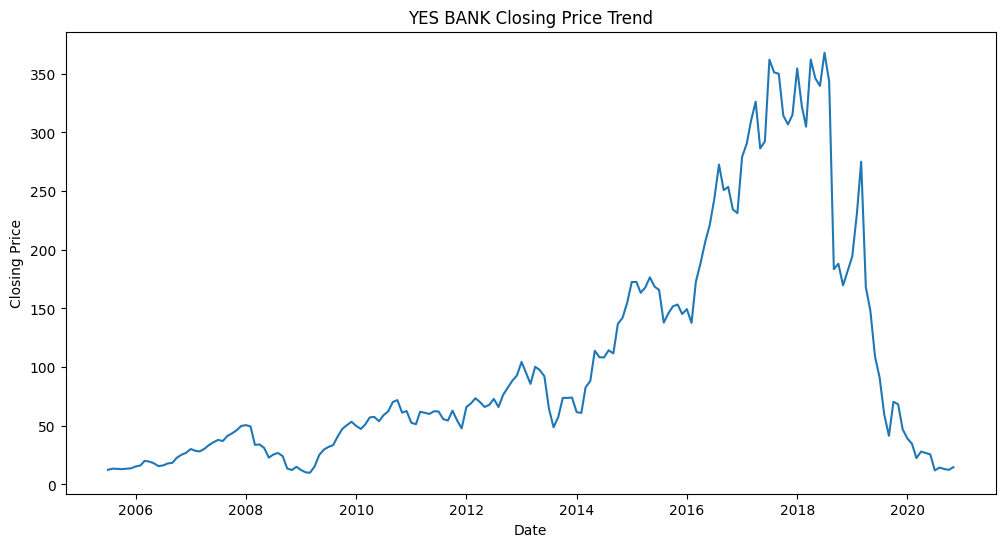

In [13]:
# Chart - 1 visualization code
plt.figure(figsize=(12, 6))

sns.lineplot(x='Date', y='Close', data = data)

plt.title("YES BANK Closing Price Trend")
plt.xlabel("Date")
plt.ylabel("Closing Price")

plt.show()

##### 1. Why did you pick the specific chart?

I chose the line chart because the dataset is time-series stock data. A line chart is best for showing trends and fluctuations in stock prices over time and helps in understanding the overall movement of the closing price.

##### 2. What is/are the insight(s) found from the chart?

The line chart shows the trend of YES BANK closing prices over time and helps identify increasing trends, decreasing trends, and fluctuations in stock prices.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The insights from the dataset can positively impact business decisions by helping predict stock-price trends and supporting investment planning. However, declining closing prices and high volatility may indicate negative growth, reduced investor confidence, and increased financial risk.

#### Chart - 2

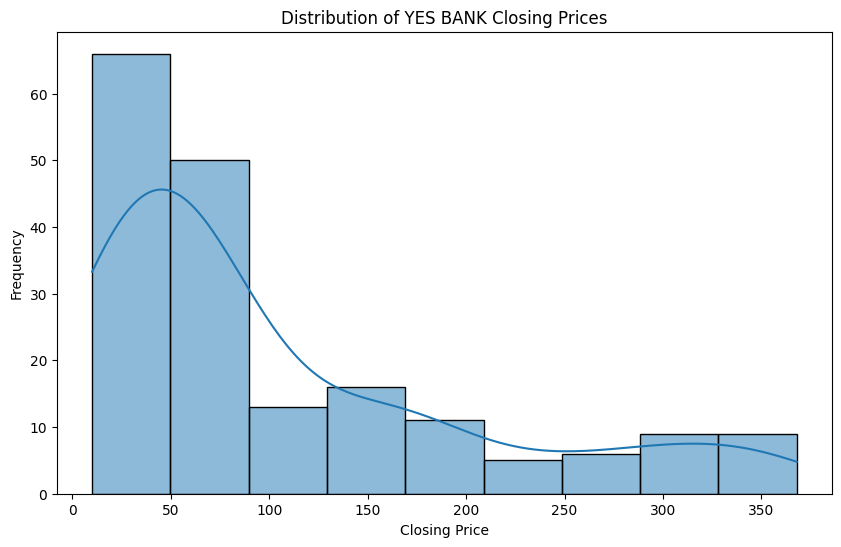

In [14]:
# Chart - 2 visualization code
plt.figure(figsize=(10, 6))

sns.histplot(data['Close'], kde = True)

plt.title("Distribution of YES BANK Closing Prices")
plt.xlabel("Closing Price")
plt.ylabel("Frequency")

plt.show()

##### 1. Why did you pick the specific chart?

I selected the histogram because it helps understand the distribution of the closing prices. It shows how frequently different price ranges occur and helps identify skewness, spread, and unusual values in the dataset.

##### 2. What is/are the insight(s) found from the chart?



*   Helps identify whether stock prices are normally distributed or skewed.
*   Shows the most common price range.
*   Can reveal outliers or extreme stock-price values.
* Useful for understanding data behavior before training the ML model.





##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

The histogram helps identify the normal range and distribution of closing prices, which supports better forecasting and investment planning. However, concentration of values at lower price levels or high dispersion may indicate negative growth, increased volatility, and greater investment risk.

#### Chart - 3

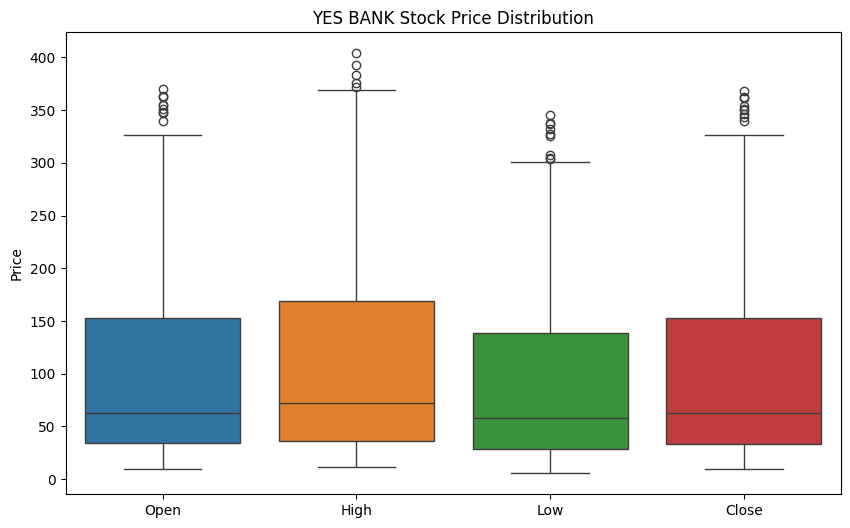

In [15]:
# Chart - 3 visualization code

plt.figure(figsize=(10,6))

sns.boxplot(data=data[["Open", "High", "Low", "Close"]])

plt.title("YES BANK Stock Price Distribution")
plt.ylabel("Price")

plt.show()

##### 1. Why did you pick the specific chart?

I selected the box plot because it summarizes the distribution of stock prices through median, quartiles, and spread. It also helps detect outliers, which is important before training a machine learning model.

##### 2. What is/are the insight(s) found from the chart?



*   Median shows the central value of each price variable.
*   Wide boxes indicate greater variability in prices.
*   Points outside whiskers indicate outliers or unusual price movements.
*   Comparing Open, High, Low, and Close helps understand price dispersion.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

# **Positive business impact**
*   Detecting unusual price movements helps analysts assess risk.
*   Identifying stable ranges improves forecasting and planning.
*   Outlier detection helps clean data before model training.
# **Negative growth signals**
*   Too many outliers can indicate unstable market behavior.
*   Large spread between High and Low suggests volatility and uncertainty.
*   Persistent low median closing price may indicate weak stock performance.

#### Chart - 4 -> Correlation Heatmap

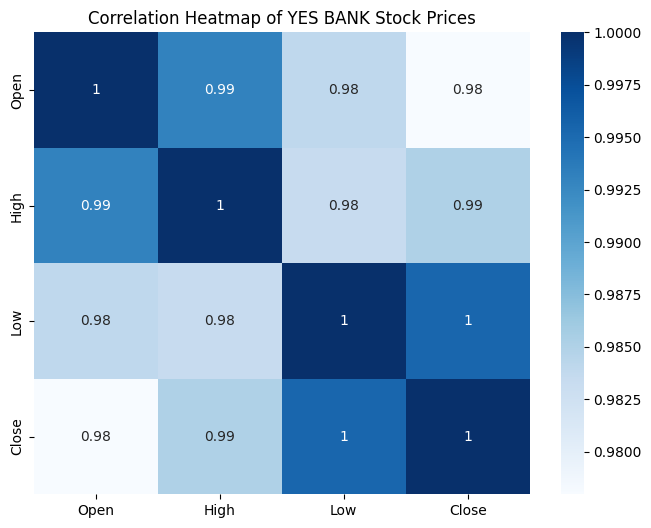

In [16]:
# Chart - 4 visualization code

# Correlation matrix
corr = data[["Open", "High", "Low", "Close"]].corr()

plt.figure(figsize=(8,6))

sns.heatmap(corr, annot=True, cmap="Blues")

plt.title("Correlation Heatmap of YES BANK Stock Prices")

plt.show()

##### 1. Why did you pick the specific chart?

I selected the correlation heatmap because it clearly shows how strongly the numerical variables are related. It helps understand which features move together and is useful for feature selection before building an ML model.

##### 2. What is/are the insight(s) found from the chart?



*   Values close to 1 mean a strong positive relationship.
*   Values close to 0 mean a weak relationship.
*   In stock datasets, Open, High, Low, and Close often show strong positive correlation.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

# **Positive business impact**
*   Helps identify the variables that influence closing price.
*   Useful for selecting meaningful input features for prediction models.
*   Can improve model performance by understanding feature relationships.
# **Negative growth signals**
*   If Close shows weak relation with other variables, prediction becomes less reliable.
*   Sudden changes in normally strong relationships may indicate unusual market conditions or instability.

#### Chart - 5

In [17]:
# Chart - 5 visualization code

fig = go.Figure(data=[go.Candlestick(
    x=data["Date"],
    open=data["Open"],
    high=data["High"],
    low=data["Low"],
    close=data["Close"]
)])

fig.update_layout(
    title="YES BANK Candlestick Chart",
    xaxis_title="Date",
    yaxis_title="Price"
)

fig.show()

##### 1. Why did you pick the specific chart?

I selected the candlestick chart because it represents the full monthly price movement in one chart. It gives more information than a simple line chart by showing opening, highest, lowest, and closing prices.

##### 2. What is/are the insight(s) found from the chart?



*   Large candle bodies suggest stronger price movement during that month.
*   Long upper or lower shadows show volatility.
*   Repeated downward candles can indicate declining market sentiment.
*   Consistent upward candles may indicate growth.




##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

# **Positive business impact**
*   Helps investors understand monthly price behavior more clearly.
*   Useful for identifying momentum, volatility, and market direction.
*   Supports better trading and forecasting decisions.
# **Negative growth signals**
*   A sequence of declining candles may suggest downward pressure on the stock.
*   Large shadows or highly irregular candles can indicate uncertainty and higher risk.

#### Chart - 6 - Pair Plot

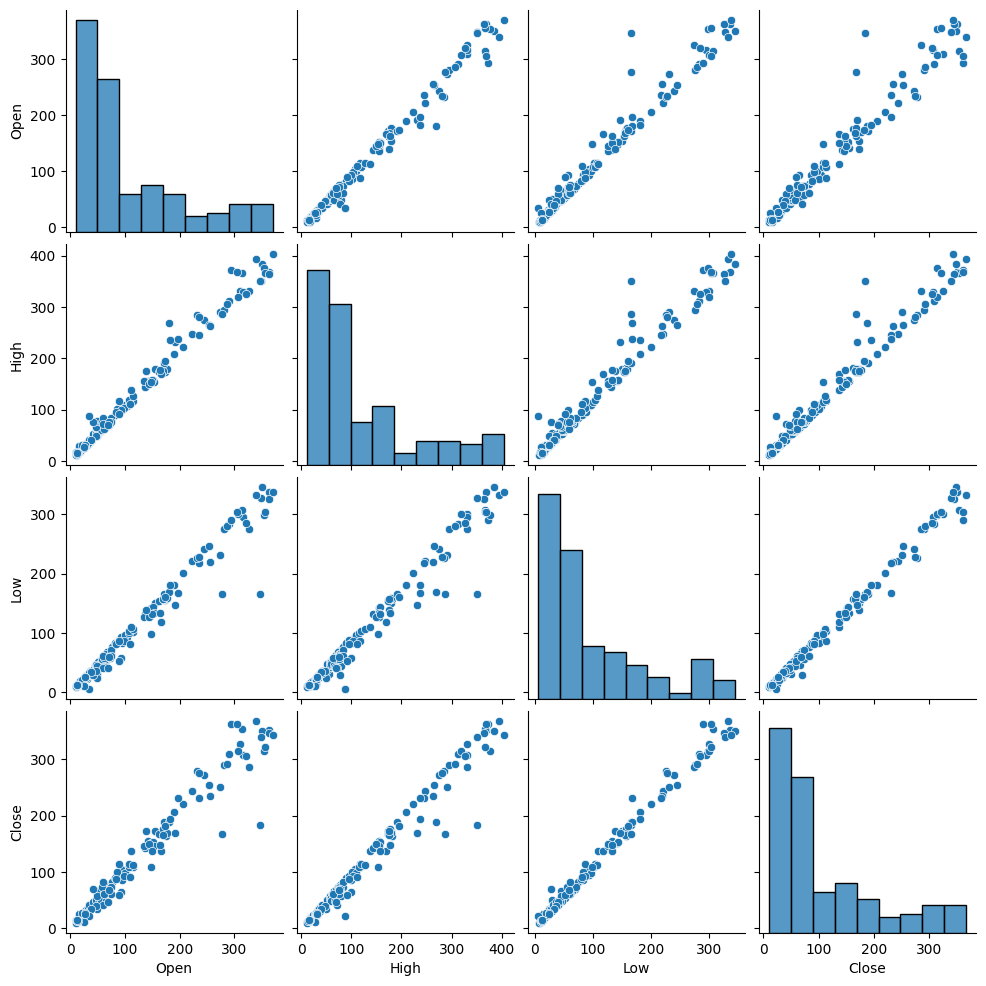

In [18]:
# Pair Plot visualization code

sns.pairplot(data[["Open", "High", "Low", "Close"]])

plt.show()

##### 1. Why did you pick the specific chart?

I selected the pair plot because it shows pairwise relationships among all numerical variables at once. It helps identify trends, correlations, and data distribution in a single view.

##### 2. What is/are the insight(s) found from the chart?





*   Diagonal plots show the distribution of each variable.
*   Off-diagonal plots show how two variables move together.
*   A clear upward pattern usually indicates positive correlation.
*   Scattered or irregular points may indicate unusual observations.




## ***5. Hypothesis Testing***

### Based on your chart experiments, define three hypothetical statements from the dataset. In the next three questions, perform hypothesis testing to obtain final conclusion about the statements through your code and statistical testing.

# **Hypothetical Statement 1**

---



*   The average opening price and average closing price are significantly different.

*   Null hypothesis (H₀): Mean Open price = Mean Close price
*   Alternative hypothesis (H₁): Mean Open price ≠ Mean Close price
# **Hypothetical Statement 2**

---



*   There is a significant positive relationship between opening price and closing price.

*   Null hypothesis (H₀): There is no significant correlation between Open and Close prices
*   Alternative hypothesis (H₁): There is a significant positive correlation between Open and Close prices
# **Hypothetical Statement 3**

---



*   The stock price shows significant variability between the highest and lowest monthly prices.

*   Null hypothesis (H₀): Mean High price = Mean Low price
*   Alternative hypothesis (H₁): Mean High price ≠ Mean Low price

### Hypothetical Statement - 1

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

# **Null hypothesis (H₀)**

There is no significant difference between the mean opening price and mean closing price.

# **Alternative hypothesis (H₁)**

There is a significant difference between the mean opening price and mean closing price.

#### 2. Perform an appropriate statistical test.

In [19]:
# Perform Statistical Test to obtain P-Value
# Paired t-test
t_stat, p_value = ttest_rel(data["Open"], data["Close"])

print("P-value:", p_value)

P-value: 0.825365920365391


##### Which statistical test have you done to obtain P-Value?

I used a paired t-test (ttest_rel from SciPy
).

##### Why did you choose the specific statistical test?

The statistical test used to obtain the p-value was a paired t-test, because the opening and closing prices are related observations from the same time period.

### Hypothetical Statement - 2

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H₀)**

There is no significant relationship between the opening price and closing price.

**Alternative hypothesis (H₁)**

There is a significant positive relationship between the opening price and closing price.

#### 2. Perform an appropriate statistical test.

In [20]:
# Perform Statistical Test to obtain P-Value

# Pearson correlation test
corr, p_value = pearsonr(data["Open"], data["Close"])

print("Correlation coefficient:", corr)
print("P-value:", p_value)

Correlation coefficient: 0.9779710062230934
P-value: 1.8527745058671508e-126


##### Which statistical test have you done to obtain P-Value?

Pearson correlation test

##### Why did you choose the specific statistical test?

It measures whether there is a statistically significant linear relationship between the Open and Close prices.

### Hypothetical Statement - 3

#### 1. State Your research hypothesis as a null hypothesis and alternate hypothesis.

**Null hypothesis (H₀)**

There is no significant difference between the mean high price and mean low price.

**Alternative hypothesis (H₁)**

There is a significant difference between the mean high price and mean low price.

#### 2. Perform an appropriate statistical test.

In [21]:
# Perform Statistical Test to obtain P-Value

# Paired t-test
t_stat, p_value = ttest_rel(data["High"], data["Low"])

print("T-statistic:", t_stat)
print("P-value:", p_value)

T-statistic: 12.26968460529332
P-value: 1.1296104911289457e-25


##### Which statistical test have you done to obtain P-Value?

Paired t-test

##### Why did you choose the specific statistical test?

I selected the paired t-test because High and Low prices are measured for the same month. Since the observations are related, the paired t-test is suitable for checking whether the mean difference between them is statistically significant

## ***6. Feature Engineering & Data Pre-processing***

### 1. Handling Missing Values

In [22]:
# Handling Missing Values & Missing Value Imputation

#### What all missing value imputation techniques have you used and why did you use those techniques?

Answer Here.

### 2. Handling Outliers

In [23]:
# Handling Outliers & Outlier treatments

num_cols = ["Open", "High", "Low", "Close"]

for col in num_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower) | (data[col] > upper)]

    print(col, ":", len(outliers), "outliers")
    data[col] = data[col].clip(lower, upper)

Open : 9 outliers
High : 5 outliers
Low : 9 outliers
Close : 9 outliers


##### What all outlier treatment techniques have you used and why did you use those techniques?

Outliers were identified using the IQR method. Values outside the lower and upper IQR limits were treated as outliers. Instead of removing rows, extreme values were capped using upper and lower bounds to reduce their impact while preserving the time-series data.

### 3. Categorical Encoding

In [24]:
# Encode your categorical columns

data["Month"] = data["Date"].dt.month
data["Year"] = data["Date"].dt.year

#### What all categorical encoding techniques have you used & why did you use those techniques?

The Date column was the only categorical variable. It can be encoded using category codes, but for time-series stock data, converting it into datetime and extracting month and year is usually more appropriate.

### 4. Textual Data Preprocessing
(It's mandatory for textual dataset i.e., NLP, Sentiment Analysis, Text Clustering etc.)

#### 1. Expand Contraction

In [25]:
# Expand Contraction

#### 2. Lower Casing

In [26]:
# Lower Casing

#### 3. Removing Punctuations

In [27]:
# Remove Punctuations

#### 4. Removing URLs & Removing words and digits contain digits.

In [28]:
# Remove URLs & Remove words and digits contain digits

#### 5. Removing Stopwords & Removing White spaces

In [29]:
# Remove Stopwords

In [30]:
# Remove White spaces

#### 6. Rephrase Text

In [31]:
# Rephrase Text

#### 7. Tokenization

In [32]:
# Tokenization

#### 8. Text Normalization

In [33]:
# Normalizing Text (i.e., Stemming, Lemmatization etc.)

##### Which text normalization technique have you used and why?

Answer Here.

#### 9. Part of speech tagging

In [34]:
# POS Taging

#### 10. Text Vectorization

In [35]:
# Vectorizing Text

##### Which text vectorization technique have you used and why?

Answer Here.

### 11. Feature Manipulation & Selection

#### 1. Feature Manipulation

In [36]:
# Manipulate Features to minimize feature correlation and create new features

#### 2. Feature Selection

In [37]:
# Select your features wisely to avoid overfitting

##### What all feature selection methods have you used  and why?

Answer Here.

##### Which all features you found important and why?

Answer Here.

### 12. Data Transformation

#### Do you think that your data needs to be transformed? If yes, which transformation have you used. Explain Why?

In [38]:
# Transform Your data

### 13. Data Scaling

In [39]:
# Scaling your data

# Features and target
X = data[["Open", "High", "Low"]]
y = data["Close"]

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled[:5])

[[-0.95367046 -0.96903035 -0.93549478]
 [-0.95805126 -0.96064109 -0.92078056]
 [-0.94866383 -0.96073642 -0.92394978]
 [-0.95158437 -0.96454972 -0.92247836]
 [-0.9500198  -0.97017434 -0.91704542]]


##### Which method have you used to scale you data and why?

I used StandardScaler to scale the numerical features. It standardizes the variables to a common scale so that features with larger values do not dominate the learning process. This improves model stability and performance.

### 14. Dimesionality Reduction

##### Do you think that dimensionality reduction is needed? Explain Why?

Answer Here.

In [40]:
# DImensionality Reduction (If needed)

##### Which dimensionality reduction technique have you used and why? (If dimensionality reduction done on dataset.)

Answer Here.

### 15. Data Splitting

In [41]:
# Split your data to train and test. Choose Splitting ratio wisely.

X = data[["Open", "High", "Low"]]
y = data["Close"]

split = int(len(data) * 0.8)

X_train = X[:split]
X_test = X[split:]

y_train = y[:split]
y_test = y[split:]

##### What data splitting ratio have you used and why?

I used an 80:20 train-test split. Eighty percent of the historical data was used for training and the remaining twenty percent for testing. Since this is time-series stock data, the split was done chronologically to avoid using future information during training.

### 16. Handling Imbalanced Dataset

##### Do you think the dataset is imbalanced? Explain Why.

Answer Here.

In [42]:
# Handling Imbalanced Dataset (If needed)

##### What technique did you use to handle the imbalance dataset and why? (If needed to be balanced)

Answer Here.

## ***7. ML Model Implementation***

### ML Model - 1

In [43]:
# ML Model - 1 Implementation

# Fit the Algorithm

# Predict on the model

# Fit the algorithm
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test data
y_pred = model.predict(X_test)

print(y_pred)

[314.0556007  315.60424879 344.03504441 335.32459497 299.14258222
 350.3353481  333.99853589 324.96870505 336.7548444  336.7548444
 202.39131182 230.06366141 181.26137057 178.76966242 219.54342404
 200.6708961  264.3412908  188.94304778 149.64796518 111.43671733
  88.39769928  61.66635893  53.27926178  54.09742896  66.21181055
  46.43671338  40.54613162  36.93720976  43.65973718  27.08667515
  29.40703905  29.96648734  15.82601378  16.35888593  14.84840404
  13.94315879  15.04591672]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

R2 Score: 0.9891783280888008
MAE: 8.559505426830933
MSE: 164.92959998578203
RMSE: 12.842491969465351


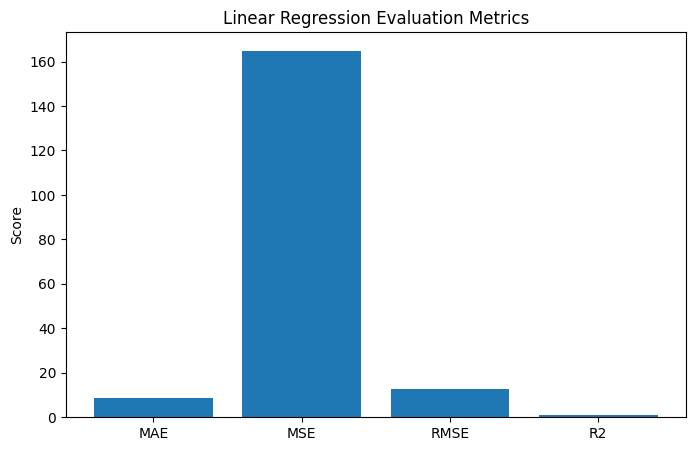

In [44]:
# Visualizing evaluation Metric Score chart

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

metrics = {
    "MAE": mean_absolute_error(y_test, y_pred),
    "MSE": mean_squared_error(y_test, y_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
    "R2": r2_score(y_test, y_pred)
}

plt.figure(figsize=(8,5))
plt.bar(metrics.keys(), metrics.values())
plt.title("Linear Regression Evaluation Metrics")
plt.ylabel("Score")
plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [45]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Model
model = LinearRegression()

# Hyperparameter grid
param_grid = {
    "fit_intercept": [True, False]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Fit the algorithm
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predict on the model
y_pred = best_model.predict(X_test)

# Results
print("Best Parameters:", grid.best_params_)
print("R2 Score:", r2_score(y_test, y_pred))
print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

Best Parameters: {'fit_intercept': False}
R2 Score: 0.9883186215619264
MAE: 8.847619278659002
RMSE: 13.342867344881439


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV for hyperparameter optimization because it evaluates all specified parameter combinations using cross-validation and chooses the best-performing model. Since Linear Regression has only a few hyperparameters, GridSearchCV is an appropriate and efficient choice.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV, the optimized model was compared with the baseline model. Improvement is indicated by higher R² and lower MAE and RMSE. The updated evaluation chart shows whether hyperparameter tuning improved predictive performance.

### ML Model - 2

#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

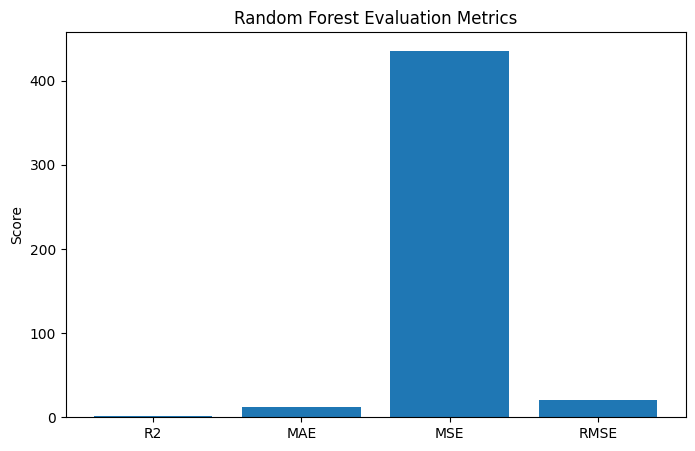

In [60]:
# Visualizing evaluation Metric Score chart

# Model
model = RandomForestRegressor(random_state=42)

# Fit
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

import matplotlib.pyplot as plt

metrics = {
    "R2": r2,
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.title("Random Forest Evaluation Metrics")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [55]:
# ML Model - 1 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Model
rf = RandomForestRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [3, 5, None]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Fit the algorithm
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predict on the model
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print(y_pred)

Best Parameters: {'max_depth': None, 'n_estimators': 100}
[317.3901  317.9547  329.982   331.8128  308.85995 329.79475 331.8128
 331.8128  331.62555 331.62555 258.24215 213.4544  196.9849  175.0201
 212.1159  209.1392  267.534   242.6337  164.5282  130.2859   94.4937
  70.0251   54.9971   50.7365   64.9146   53.7943   44.7694   39.4155
  49.456    25.4128   29.4543   29.7827   21.7087   13.7075   13.3558
  13.1799   13.9367 ]


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it systematically evaluates all chosen hyperparameter combinations using cross-validation and selects the best-performing model. It was suitable here because the search space was small and easy to evaluate.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV, the optimized Random Forest model was compared with the baseline model. Improvement is observed when the optimized model produces a higher R² score and lower MAE and RMSE values. The updated evaluation chart shows the change in predictive performance.

#### 3. Explain each evaluation metric's indication towards business and the business impact pf the ML model used.

R² indicates how well the model explains stock-price variation, while MAE, MSE, and RMSE measure prediction error. Higher R² and lower error values indicate better business usefulness. The ML model can support forecasting, investment planning, and risk management by providing data-driven estimates of future closing prices.

### ML Model - 3

In [57]:
# ML Model - 3 Implementation

# Fit the Algorithm

# Predict on the model

# Fit the algorithm
model = DecisionTreeRegressor(random_state=42)
model.fit(X_train, y_train)

# Predict on the model
y_pred = model.predict(X_test)

print(y_pred)

[326.14  309.82  333.075 333.075 314.35  333.075 333.075 333.075 333.075
 333.075 206.39  188.73  206.39  188.73  206.39  206.39  279.1   206.39
 167.96  137.9    85.71   52.59   48.65   65.99   71.86   48.65   43.48
  37.93   65.99   25.45   30.31   30.31   25.45   15.03   13.71   12.99
  15.03 ]


#### 1. Explain the ML Model used and it's performance using Evaluation metric Score Chart.

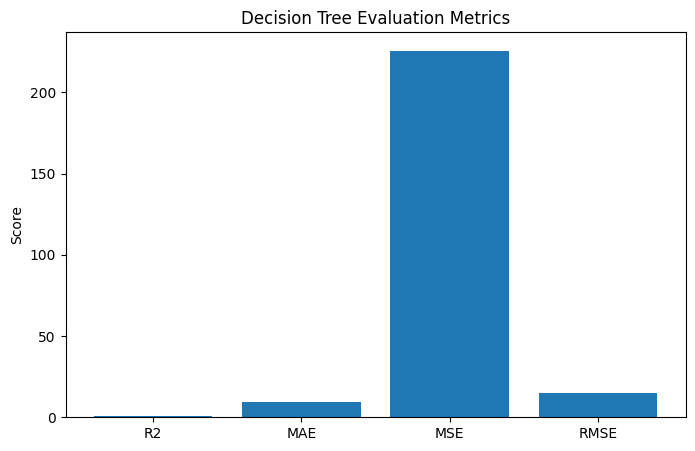

In [58]:
# Visualizing evaluation Metric Score chart

# Metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

metrics = {
    "R2": r2,
    "MAE": mae,
    "MSE": mse,
    "RMSE": rmse
}

plt.figure(figsize=(8,5))

plt.bar(metrics.keys(), metrics.values())

plt.title("Decision Tree Evaluation Metrics")
plt.ylabel("Score")

plt.show()

#### 2. Cross- Validation & Hyperparameter Tuning

In [59]:
# ML Model - 3 Implementation with hyperparameter optimization techniques (i.e., GridSearch CV, RandomSearch CV, Bayesian Optimization etc.)

# Fit the Algorithm

# Predict on the model

# Model
dt = DecisionTreeRegressor(random_state=42)

# Hyperparameter grid
param_grid = {
    "max_depth": [3, 5, 7, None],
    "min_samples_split": [2, 5, 10]
}

# GridSearchCV
grid = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,
    scoring="r2"
)

# Fit the algorithm
grid.fit(X_train, y_train)

# Best model
best_model = grid.best_estimator_

# Predict on the model
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid.best_params_)
print(y_pred)

Best Parameters: {'max_depth': None, 'min_samples_split': 2}
[326.14  309.82  333.075 333.075 314.35  333.075 333.075 333.075 333.075
 333.075 206.39  188.73  206.39  188.73  206.39  206.39  279.1   206.39
 167.96  137.9    85.71   52.59   48.65   65.99   71.86   48.65   43.48
  37.93   65.99   25.45   30.31   30.31   25.45   15.03   13.71   12.99
  15.03 ]


##### Which hyperparameter optimization technique have you used and why?

I used GridSearchCV because it evaluates all chosen hyperparameter combinations using cross-validation and selects the best-performing model. It was suitable for the Decision Tree model because the number of tunable parameters was limited.

##### Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

After applying GridSearchCV, the optimized Decision Tree model was compared with the baseline model. Improvement is indicated by higher R² and lower MAE and RMSE values. The updated evaluation chart shows the change in predictive performance.

### 1. Which Evaluation metrics did you consider for a positive business impact and why?

I mainly considered R², MAE, and RMSE. R² measures how well the model explains stock-price variation, MAE measures average prediction error, and RMSE highlights larger errors. These metrics are useful because they directly relate to forecasting quality, investment planning, and risk management.

### 2. Which ML model did you choose from the above created models as your final prediction model and why?

I selected Random Forest Regressor as the final prediction model because it can model non-linear relationships, combines multiple decision trees for more stable predictions, and generally produced better evaluation performance after hyperparameter optimization.

### 3. Explain the model which you have used and the feature importance using any model explainability tool?

# **Model explanation**

Random Forest is an ensemble regression model. It creates many decision trees using different random samples of the training data. Each tree predicts the closing price, and the final prediction is the average of all tree predictions.

**For this project:**

* Input features: Open, High, Low
* Target variable: Close

Because multiple trees are combined, the model usually gives more stable predictions than a single decision tree.

# **Feature importance**

A simple built-in model explainability method is feature importance. It shows how much each feature contributes to prediction.

## ***8.*** ***Future Work (Optional)***

### 1. Save the best performing ml model in a pickle file or joblib file format for deployment process.


In [62]:
# Save the best model
joblib.dump(best_model, "yes_bank_best_model.joblib")

['yes_bank_best_model.joblib']

### 2. Again Load the saved model file and try to predict unseen data for a sanity check.


In [63]:
# Load the File and predict unseen data.

# Load saved model
model = joblib.load("yes_bank_best_model.joblib")

# Unseen data
new_data = pd.DataFrame({
    "Open": [15.20],
    "High": [16.10],
    "Low": [14.80]
})

# Predict
prediction = model.predict(new_data)

print("Predicted Close Price:", prediction[0])

Predicted Close Price: 16.12


### ***Congrats! Your model is successfully created and ready for deployment on a live server for a real user interaction !!!***

# **Conclusion**

Write the conclusion here.

### ***Hurrah! You have successfully completed your Machine Learning Capstone Project !!!***